# 1. Two Sum

Given an array of integers nums and an integer target, return indices of the two numbers such that they add up to target.

You may assume that each input would have exactly one solution, and you may not use the same element twice.

You can return the answer in any order.

 

Example 1:

Input: nums = [2,7,11,15], target = 9
Output: [0,1]
Explanation: Because nums[0] + nums[1] == 9, we return [0, 1].
Example 2:

Input: nums = [3,2,4], target = 6
Output: [1,2]
Example 3:

Input: nums = [3,3], target = 6
Output: [0,1]
 

In [4]:
class Solution:
    def twoSum(self, nums, target: int):
        """
        Linear Time --> O(n)
        Space Time --> O(n)
        """
        # for i in range(len(nums)):
        #     diff = (target - nums[i])
        #     if diff in nums[i+1:]:  # O(n2)
        #         return [i, nums[i+1:].index(diff)+i+1]
        seen = dict()
        for i, num in enumerate(nums):
            diff = target - nums[i]
            if diff in seen:
                return [i, seen[diff]] 
            seen[num] = i

# 11. Container With Most Water
Medium

Hint - 
You are given an integer array height of length **n**. There are **n** vertical lines drawn such that the two endpoints of the **ith** line are **(i, 0)** and **(i, height[i])**.

Find two lines that together with the x-axis form a container, such that the container contains the most water.

Return the maximum amount of water a container can store.

**Notice that you may not slant the container.**

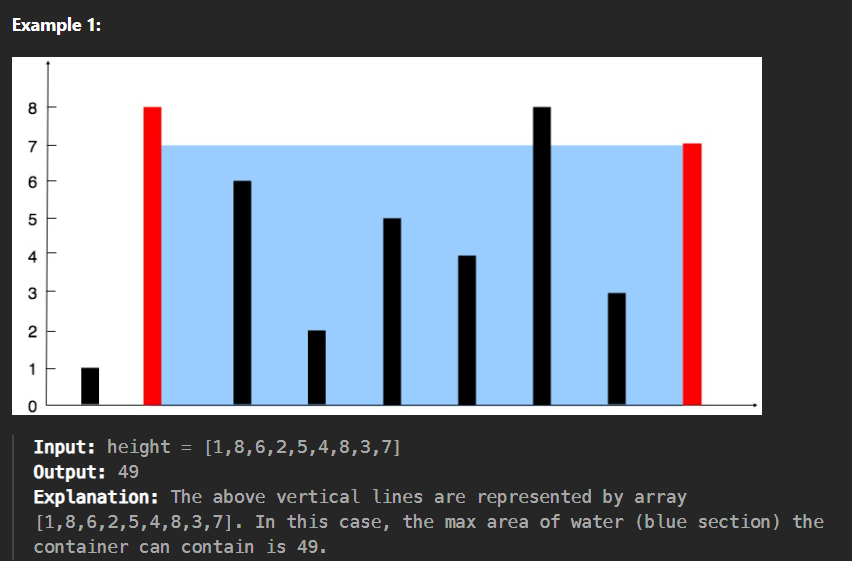

In [8]:
### two pointer approach
"""
Start one pointer on left and another pointer on right side. 
1. Calculate the area of this first iteration.
2. check if left is lesser than right --> move left = left+1
3. check if left is greater than right --> move right = right-1
4. Do this till left <= right
"""

In [15]:
class Solution:
    def maxArea(self, height) -> int:
        max_area = 0
        left, right = 0, len(height)-1
        
        while left < right:
            print(f"left= {left}")
            area = (right-left) * min(height[left], height[right])
            print(area)
            max_area = max(max_area, area)

            if height[left] < height[right]:
                left = left + 1
            else:
                right = right-1
        return max_area
s1 = Solution()
s1.maxArea([5,6,7,8,9])

left= 0
20
left= 1
18
left= 2
14
left= 3
8


20

## 977. Squares of a Sorted Array
Easy
Given an integer array nums sorted in non-decreasing order, return an array of the squares of each number sorted in non-decreasing order.

 

Example 1:

Input: nums = [-4,-1,0,3,10]
Output: [0,1,9,16,100]
Explanation: After squaring, the array becomes [16,1,0,9,100].
After sorting, it becomes [0,1,9,16,100].
Example 2:

Input: nums = [-7,-3,2,3,11]
Output: [4,9,9,49,121]

In [17]:
class Solution:
    def sortedSquares(self, nums: []) -> []:
        res = []
        left = 0 
        right = len(nums)-1
        while left <= right:
            if nums[right]**2 > nums[left]**2:
                ## Bad Practice , bcoz array shifts all   elements to insert into first
                # res.insert(0, nums[right]**2)  

                res.append(nums[right]**2)
                right = right-1
            else:
                # res.insert(0, nums[left]**2)

                res.append(nums[left]**2)
                left = left +1
        return list(reversed(res))  # res[::-1]  --> this is also slower
            

## 567. Permutation in String
Medium

Hint
Given two strings s1 and s2, return true if s2 contains a permutation of s1, or false otherwise.

In other words, return true if one of s1's permutations is the substring of s2.

 

Example 1:

Input: s1 = "ab", s2 = "eidbaooo"
Output: true
Explanation: s2 contains one permutation of s1 ("ba").
Example 2:

Input: s1 = "ab", s2 = "eidboaoo"
Output: false

In [19]:
### Sliding Window 

In [20]:
"""
Brute Force - first find permutation of S1 then search one by one in S2.
"""

'\nBrute Force - first find permutation of S1 then search one by one in S2.\n'

In [21]:
from collections import defaultdict
class Solution:
    def checkInclusion(self, s1: str, s2: str) -> bool:
        """
        Step 1: create the target_freq_dict for s1 and curr_freq_dict
        Step 2: create the fixed window size of len(s1)
        Step 3: go till end of s2
                add the chars in curr_freq_dict as per window 
                increase the entering element and decrease the leaving element.
        Step 4: Compare curr_freq_dict and target_freq_dict

        ei dbaooo
        01 234567
        """
        if len(s2) < len(s1):
            return False  # edge case

        target_ctr, curr_ctr = defaultdict(int), defaultdict(int)
        # scanning the initial length of string
        for i in range(len(s1)):
            target_ctr[s1[i]] +=1
            curr_ctr[s2[i]] +=1
        if curr_ctr == target_ctr:
            return True  # checking initial condition
        
        for i in range(len(s1), len(s2)):
            entering_element = s2[i]
            leaving_element = s2[i-len(s1)]

            curr_ctr[entering_element] +=1
            curr_ctr[leaving_element] -=1
            if curr_ctr[leaving_element] == 0:
                del curr_ctr[leaving_element]

            # compart the current ctr and target ctr 
            if curr_ctr == target_ctr:
                return True
        return False


        